In [54]:

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import joblib
from sklearn.impute import SimpleImputer


In [55]:
df = pd.read_csv("/content/drive/MyDrive/Major Project/Model training/train_scaled_processed.csv")


In [56]:
X = df.drop(['Fatigue', 'dopamine_score', 'health_score', 'lifestyle_risk'], axis=1)

all_nan_columns = X.columns[X.isnull().all()].tolist()
if all_nan_columns:
    print(f"Dropping columns with all missing values: {all_nan_columns}")
    X = X.drop(columns=all_nan_columns)

Dropping columns with all missing values: ['Gender', 'bmi_category']


In [57]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)


In [58]:
X = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

In [59]:
print("\nCluster Distribution:")
print(df['Cluster'].value_counts())

print("\nCluster Behavior:")
print(df.groupby('Cluster').mean())


Cluster Distribution:
Cluster
0    2171
2    2165
1    1264
Name: count, dtype: int64

Cluster Behavior:
         ScreenTime  SleepHours  LateNightUsage  ActivityLevel  DietQuality  \
Cluster                                                                       
0          0.029276   -0.000163        0.000891      -0.020091     0.007037   
1          0.013407    0.017054       -0.003016      -0.024022    -1.224834   
2         -0.037184   -0.009793        0.000867       0.034172     0.708043   

         SittingTime  InactivityPeriods  StressLevel  Gender  MealsPerDay  \
Cluster                                                                     
0          -0.013750          -0.016011     0.016203     NaN     1.081747   
1          -0.067006          -0.010345     0.013703     NaN    -0.607358   
2           0.052908           0.022095    -0.024249     NaN    -0.730149   

         ...  DigitalLoad  LateNightImpact  ActivityScore  SedentaryIndex  \
Cluster  ...                       

In [60]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

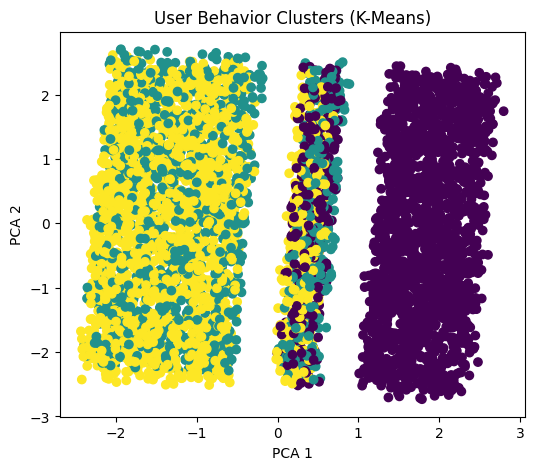

In [61]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("User Behavior Clusters (K-Means)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [62]:
df.groupby('Cluster').mean()

,ScreenTime,SleepHours,LateNightUsage,ActivityLevel,DietQuality,SittingTime,InactivityPeriods,StressLevel,Gender,MealsPerDay,...,DigitalLoad,LateNightImpact,ActivityScore,SedentaryIndex,CalorieBalance,MealScore,DietScore,StressScore,DopamineScore,FatigueIndex
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.029276,-0.000163,0.000891,-0.020091,0.007037,-0.013750,-0.016011,0.016203,NaN,1.081747,...,0.029276,0.010314,-0.016851,-0.009904,0.000515,0.679482,0.005801,0.013530,-0.005678,0.251932
1,0.013407,0.017054,-0.003016,-0.024022,-1.224834,-0.067006,-0.010345,0.013703,NaN,-0.607358,...,0.013407,-0.017981,-0.020148,-0.025741,-0.000274,-0.381502,-1.009690,0.011443,-0.024672,0.244078
2,-0.037184,-0.009793,0.000867,0.034172,0.708043,0.052908,0.022095,-0.024249,NaN,-0.730149,...,-0.037184,-0.000356,0.028661,0.024960,-0.000356,-0.458631,0.583674,-0.020248,0.020098,0.251469


In [63]:
cluster_map = {
    0: "Healthy",
    1: "Sedentary",
    2: "High Risk"
}

df['Behavior_Type'] = df['Cluster'].map(cluster_map)

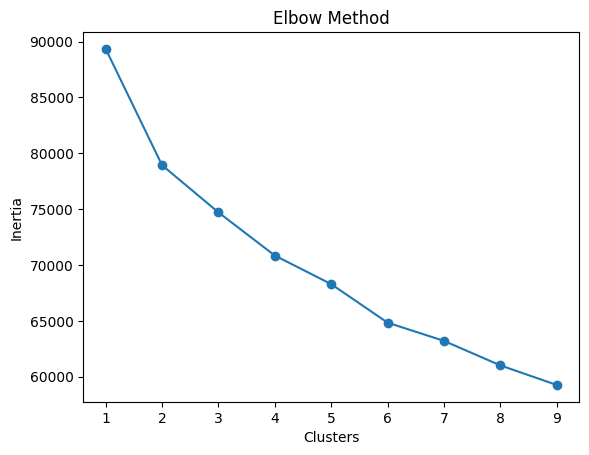

['kmeans_pca.pkl']

In [64]:
inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(imputer, 'kmeans_imputer.pkl')
joblib.dump(pca, 'kmeans_pca.pkl')

In [66]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN


In [67]:
df = pd.read_csv("/content/drive/MyDrive/Major Project/Model training/train_scaled_processed.csv")

In [68]:
drop_cols = ['Fatigue']
X = df.drop(columns=drop_cols, errors='ignore')
X = X.dropna(axis=1, how='all')
feature_columns = X.columns

In [69]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X = pd.DataFrame(X, columns=feature_columns)


In [70]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)


In [71]:
dbscan = DBSCAN(eps=1.0, min_samples=8)
db_labels = dbscan.fit_predict(X_pca)

df['DBSCAN_Cluster'] = db_labels

df['Anomaly_DBSCAN'] = df['DBSCAN_Cluster'].apply(lambda x: 1 if x == -1 else 0)

df['Behavior_Type_DBSCAN'] = df['DBSCAN_Cluster'].apply(
    lambda x: "Anomalous User" if x == -1 else "Normal User"
)


print("\nDBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts())


num_anomalies = df['Anomaly_DBSCAN'].sum()
total = len(df)

print("Number of Anomalies:", num_anomalies)
print("Anomaly %:", (num_anomalies / total) * 100)



DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0     3651
-1     1822
 3       19
 2       10
 11      10
 17       8
 8        8
 6        8
 10       7
 13       7
 4        6
 5        6
 12       6
 9        6
 15       6
 14       6
 16       6
 7        4
 1        4
Name: count, dtype: int64
Number of Anomalies: 1822
Anomaly %: 32.535714285714285


In [72]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)


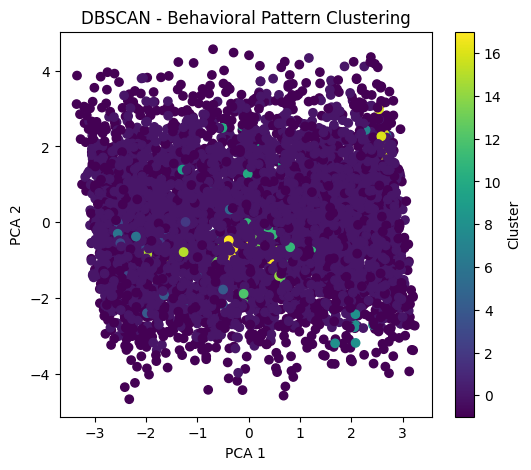

In [73]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=db_labels, cmap='viridis')
plt.title("DBSCAN - Behavioral Pattern Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()

In [74]:
cluster_behavior = df.groupby('DBSCAN_Cluster').mean(numeric_only=True)
print("\nCluster Behavior Summary:")
print(cluster_behavior)

df.to_csv("dbscan_behavior_output.csv", index=False)


Cluster Behavior Summary:
                ScreenTime  SleepHours  LateNightUsage  ActivityLevel  \
DBSCAN_Cluster                                                          
-1               -0.000031   -0.047181       -0.001334      -0.113364   
 0                0.010860    0.032435       -0.002683       0.067360   
 1               -0.120603    0.265025        0.009643       1.192293   
 2               -0.926176   -0.657094       -0.190366      -1.131576   
 3               -1.283700   -1.133390       -0.148259      -0.674527   
 4               -0.664909   -0.514130       -0.323706       0.173053   
 5               -0.302038    0.572398        0.342992       0.988445   
 6               -1.481369   -0.903707        0.259655      -0.948112   
 7                1.512316    0.458026        0.509667      -0.948112   
 8                0.968010   -0.582038        0.009643      -1.100998   
 9               -0.882632    0.000541       -0.323706      -0.846188   
 10               0.2059

In [75]:
joblib.dump(dbscan, 'dbscan_model.pkl')
joblib.dump(imputer, 'dbscan_imputer.pkl')
joblib.dump(pca, 'dbscan_pca.pkl')

['dbscan_pca.pkl']

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
